# Linearized Hamiltonian Approximation on QM9
**Algorithm:** Linear Regression on PCA manifold  
**Field:** Quantum Chemistry & Atomistic Physics  
**Dataset:** QM9 (Quantum chemical energies)  
**Goal:** Project orbital-like descriptors (Coulomb-matrix eigs) onto a low-D regression manifold, train linear model to predict molecular energy and derive atom/bond-level approximate potentials.

**Author:** Naman Dixit  
**Date:** 22-11-2025  


In [12]:
# Install Miniconda in Colab
!wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
!bash Miniconda3-latest-Linux-x86_64.sh -b -p /usr/local

# Initialize conda
import sys
sys.path.append('/usr/local/lib/python3.8/site-packages')

# Install RDKit
!conda install -y -c conda-forge rdkit

# Install remaining libraries via pip
!pip install scikit-learn pandas numpy matplotlib seaborn tqdm joblib ase


ERROR: File or directory already exists: '/usr/local'
If you want to update an existing installation, use the -u option.
/bin/bash: line 1: conda: command not found
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 28.6 MB/s eta 0:00:00


In [13]:
import os, math, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
import joblib
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
plt.rcParams.update({'figure.dpi':120})
sns.set(style='whitegrid')
RND = 42
np.random.seed(RND)
warnings.filterwarnings('ignore')


In [14]:
# DATA_DIR for caching
DATA_DIR = '/content/qm9_data'
os.makedirs(DATA_DIR, exist_ok=True)

qm9_df = None

# Option A: DeepChem loader (preferred if available)
try:
    import deepchem as dc
    print("Trying DeepChem loader...")
    tasks, datasets, transformers = dc.molnet.load_qm9(featurizer=None, split='random')
    # datasets: (train, valid, test) each is a dc.data.Dataset with .X/.y/.ids
    train_ds, valid_ds, test_ds = datasets
    # deepchem loader returns X=None when featurizer=None but ids give file paths; y holds targets
    def ds_to_df(dset):
        y = dset.y
        ids = dset.ids
        df = pd.DataFrame(y, columns=tasks)
        if ids is not None:
            df['mol_id'] = ids
        return df
    train_df = ds_to_df(train_ds); valid_df = ds_to_df(valid_ds); test_df = ds_to_df(test_ds)
    qm9_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)
    print("Loaded QM9 via DeepChem. Targets columns:", qm9_df.columns.tolist()[:10])
except Exception as e:
    print("DeepChem loader not available or failed:", e)

# Option B: Try DeepChem S3 mirror (raw gdb9 dataset)
if qm9_df is None:
    try:
        print("Trying to download gdb9 tar from DeepChem S3 mirror (fast)...")
        s3_url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/gdb9.tar.gz"
        local_tar = os.path.join(DATA_DIR, "gdb9.tar.gz")
        if not os.path.exists(local_tar):
            !wget -q -O {local_tar} {s3_url}
        # extract
        !tar -xzf {local_tar} -C {DATA_DIR}
        # gdb9 files include gdb9.sdf or gdb9/ - many formats; we can parse gdb9.sdf if present
        sdf_path = os.path.join(DATA_DIR, "gdb9.sdf")
        if os.path.exists(sdf_path):
            suppl = Chem.SDMolSupplier(sdf_path)
            records = []
            for m in tqdm(suppl):
                if m is None: continue
                smi = Chem.MolToSmiles(m)
                # QM9 stores U0 etc in properties; adapt as available
                props = {p: m.GetProp(p) if m.HasProp(p) else None for p in ['U0','U','homo','lumo'] if m.HasProp(p)}
                props['smiles'] = smi
                records.append(props)
            qm9_df = pd.DataFrame(records)
    except Exception as e:
        print("S3 downloader / parser failed:", e)

# Option C: Fallback tiny demo (so notebook runs end-to-end)
if qm9_df is None:
    print("No QM9 available — creating small demo dataset (5 molecules) so pipeline runs end-to-end.")
    demo_smiles = ['CCO','CC','CCC','c1ccccc1','O']
    demo_mols = [Chem.MolFromSmiles(s) for s in demo_smiles]
    demo_targets = [Descriptors.MolWt(m) for m in demo_mols]  # proxy target (replace when QM9 available)
    qm9_df = pd.DataFrame({'smiles': demo_smiles, 'U0': demo_targets})
    qm9_df['mol_id'] = range(len(qm9_df))

print("Rows loaded:", len(qm9_df))
qm9_df.head()


Trying DeepChem loader...


[09:28:24] Explicit valence for atom # 1 C, 5, is greater than permitted
[09:28:24] ERROR: Could not sanitize molecule ending on line 2704
[09:28:24] ERROR: Explicit valence for atom # 1 C, 5, is greater than permitted
[09:28:24] Explicit valence for atom # 1 C, 5, is greater than permitted
[09:28:24] ERROR: Could not sanitize molecule ending on line 9097
[09:28:24] ERROR: Explicit valence for atom # 1 C, 5, is greater than permitted
[09:28:24] Explicit valence for atom # 2 C, 5, is greater than permitted
[09:28:24] ERROR: Could not sanitize molecule ending on line 19803
[09:28:24] ERROR: Explicit valence for atom # 2 C, 5, is greater than permitted
[09:28:24] Explicit valence for atom # 2 C, 5, is greater than permitted
[09:28:24] ERROR: Could not sanitize molecule ending on line 19870
[09:28:24] ERROR: Explicit valence for atom # 2 C, 5, is greater than permitted
[09:28:24] Explicit valence for atom # 2 C, 5, is greater than permitted
[09:28:24] ERROR: Could not sanitize molecule end

DeepChem loader not available or failed: 'NoneType' object is not callable
Trying to download gdb9 tar from DeepChem S3 mirror (fast)...


  0%|          | 0/133885 [00:00<?, ?it/s][09:28:32] Explicit valence for atom # 1 C, 5, is greater than permitted
[09:28:32] ERROR: Could not sanitize molecule ending on line 9097
[09:28:32] ERROR: Explicit valence for atom # 1 C, 5, is greater than permitted
  1%|          | 952/133885 [00:00<00:28, 4609.39it/s][09:28:33] Explicit valence for atom # 1 C, 5, is greater than permitted
[09:28:33] ERROR: Could not sanitize molecule ending on line 35785
[09:28:33] ERROR: Explicit valence for atom # 1 C, 5, is greater than permitted
  1%|▏         | 1834/133885 [00:00<00:31, 4136.65it/s][09:28:33] Explicit valence for atom # 4 C, 5, is greater than permitted
[09:28:33] ERROR: Could not sanitize molecule ending on line 62866
[09:28:33] ERROR: Explicit valence for atom # 4 C, 5, is greater than permitted
[09:28:33] Explicit valence for atom # 2 C, 5, is greater than permitted
[09:28:33] ERROR: Could not sanitize molecule ending on line 66832
[09:28:33] ERROR: Explicit valence for atom # 2 C,

Rows loaded: 132737


,smiles
0,C
1,N
2,O
3,C#C
4,C#N


In [15]:
# Ensure we have SMILES or mol_id paths
if 'smiles' not in qm9_df.columns:
    # If qm9_df has mol_id entries that are SDF/xyz paths, try to map to SMILES
    if 'mol_id' in qm9_df.columns:
        # attempt to read small set and extract SMILES
        sample_ids = qm9_df['mol_id'].dropna().unique()[:50]
        smi_list = []
        for mid in sample_ids:
            try:
                m = Chem.MolFromMolFile(mid, removeHs=False)
                if m: smi_list.append(Chem.MolToSmiles(m))
            except:
                pass
        if len(smi_list)>0:
            qm9_df = qm9_df.iloc[:len(smi_list)].copy()
            qm9_df['smiles'] = smi_list

# Basic stats
qm9_df['n_atoms'] = qm9_df['smiles'].apply(lambda s: Chem.MolFromSmiles(s).GetNumAtoms() if isinstance(s,str) else np.nan)
print("N molecules:", len(qm9_df))
print("n_atoms stats:\n", qm9_df['n_atoms'].describe())
qm9_df.head()


N molecules: 132737
n_atoms stats:
 count    132737.000000
mean          8.807469
std           0.523033
min           1.000000
25%           9.000000
50%           9.000000
75%           9.000000
max          12.000000
Name: n_atoms, dtype: float64


,smiles,n_atoms
0,C,1
1,N,1
2,O,1
3,C#C,2
4,C#N,2


In [16]:
from rdkit.Chem import AllChem
GEOM_CACHE = os.path.join(DATA_DIR, "rdkit_geoms.npy")
use_cache = os.path.exists(GEOM_CACHE)
geoms = []

def embed_optimize(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None: return None
    m = Chem.AddHs(m)
    try:
        AllChem.EmbedMolecule(m, randomSeed=RND)
        AllChem.UFFOptimizeMolecule(m, maxIters=200)
        return m
    except Exception:
        return None

if use_cache:
    print("Loading cached geometries...")
    geoms = list(np.load(GEOM_CACHE, allow_pickle=True))
else:
    print("Embedding molecules (this may be slow). Caching results...")
    for s in tqdm(qm9_df['smiles'].values):
        m = embed_optimize(s)
        geoms.append(m)
    np.save(GEOM_CACHE, np.array(geoms, dtype=object))

# attach to dataframe
qm9_df['mol'] = geoms
qm9_df = qm9_df[qm9_df['mol'].notnull()].reset_index(drop=True)
print("Molecules with valid 3D:", len(qm9_df))


Embedding molecules (this may be slow). Caching results...


100%|██████████| 132737/132737 [1:48:14<00:00, 20.44it/s]


Molecules with valid 3D: 126749


In [17]:
def raw_coulomb_matrix(mol):
    conf = mol.GetConformer()
    N = mol.GetNumAtoms()
    Z = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    coords = [np.array(conf.GetAtomPosition(i)) for i in range(N)]
    C = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            if i==j:
                C[i,j] = 0.5 * (Z[i]**2.4)
            else:
                d = np.linalg.norm(coords[i]-coords[j]) + 1e-8
                C[i,j] = (Z[i]*Z[j]) / d
    return C

# fixed feature length (pad to max_atoms)
max_atoms = int(qm9_df['n_atoms'].max())
max_atoms = max(10, max_atoms)  # ensure at least some size
feat_len = max_atoms  # we'll use eigenvalue vectors of length max_atoms

X_list = []
eigs_list = []
y_list = []
smiles_list = []
for idx, row in tqdm(qm9_df.iterrows(), total=qm9_df.shape[0]):
    mol = row['mol']
    try:
        C = raw_coulomb_matrix(mol)
        eigs = np.linalg.eigvalsh(C)
        eigs_sorted = np.sort(eigs)[::-1]
        padded = np.zeros(feat_len)
        padded[:len(eigs_sorted)] = eigs_sorted[:feat_len]
        X_list.append(padded)
        eigs_list.append(eigs_sorted)
        # target: use U0 if exists else first numeric column
        if 'U0' in qm9_df.columns:
            y_list.append(float(row['U0']))
        else:
            # pick first numeric column
            cand = qm9_df.select_dtypes(include=[np.number]).columns.tolist()
            if len(cand)>0:
                y_list.append(float(row[cand[0]]))
            else:
                y_list.append(0.0)
        smiles_list.append(row['smiles'])
    except Exception as e:
        continue

X = np.vstack(X_list)
y = np.array(y_list, dtype=float)
print("Descriptor shape X:", X.shape, "y shape:", y.shape)
# cache
np.savez(os.path.join(DATA_DIR, "qm9_coulomb_eigs.npz"), X=X, y=y, smiles=smiles_list)


100%|██████████| 126749/126749 [08:33<00:00, 246.79it/s]


Descriptor shape X: (126749, 12) y shape: (126749,)


Chose d = 8 components (cumulative var: 0.9048729421631386 )


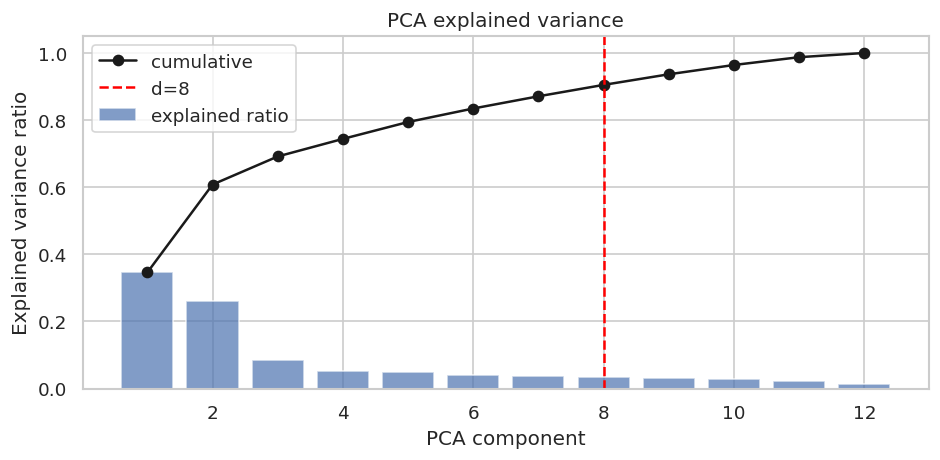

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=min(30, X_scaled.shape[1]), random_state=RND)
Z = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

# choose d: components to explain 90% variance but cap at 10
cum = np.cumsum(explained)
d = int(np.searchsorted(cum, 0.90)+1)
d = min(d, 10)
print("Chose d =", d, "components (cumulative var:", cum[d-1], ")")

# Plot 1: explained variance & cumulative
plt.figure(figsize=(8,4))
plt.bar(range(1, len(explained)+1), explained, alpha=0.7, label='explained ratio')
plt.plot(range(1,len(explained)+1), cum, marker='o', color='k', label='cumulative')
plt.axvline(d, color='red', linestyle='--', label=f'd={d}')
plt.xlabel('PCA component'); plt.ylabel('Explained variance ratio')
plt.title('PCA explained variance'); plt.legend()
plt.tight_layout(); plt.show()

Zd = Z[:, :d]


Test MAE: 0.2194, R2: 0.6626


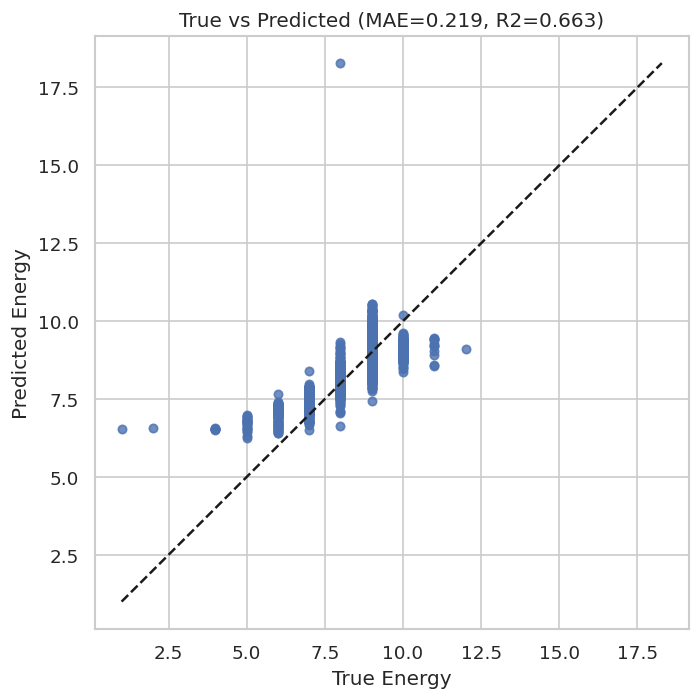

In [19]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    Zd, y, np.arange(len(y)), test_size=0.2, random_state=RND)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MAE: {mae:.4f}, R2: {r2:.4f}")

# Plot 2: True vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, s=25, alpha=0.8)
mn = min(y_test.min(), y_pred.min()); mx = max(y_test.max(), y_pred.max())
plt.plot([mn,mx],[mn,mx],'k--')
plt.xlabel('True Energy'); plt.ylabel('Predicted Energy')
plt.title(f'True vs Predicted (MAE={mae:.3f}, R2={r2:.3f})'); plt.grid(True)
plt.tight_layout(); plt.show()


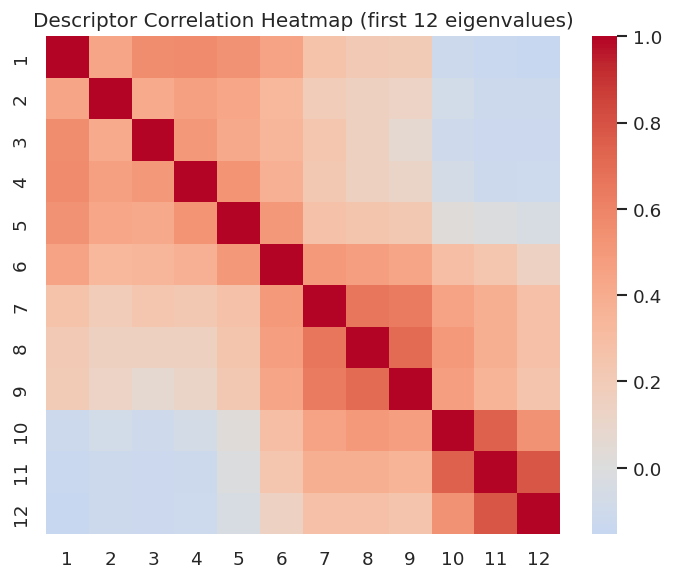

In [20]:
# Correlation heatmap of original eigenvalue features (limited to first 20 indices)
k = min(20, X.shape[1])
corr = np.corrcoef(X[:, :k].T)
plt.figure(figsize=(6,5))
sns.heatmap(corr, xticklabels=range(1,k+1), yticklabels=range(1,k+1), cmap='coolwarm', center=0)
plt.title('Descriptor Correlation Heatmap (first {} eigenvalues)'.format(k))
plt.tight_layout(); plt.show()


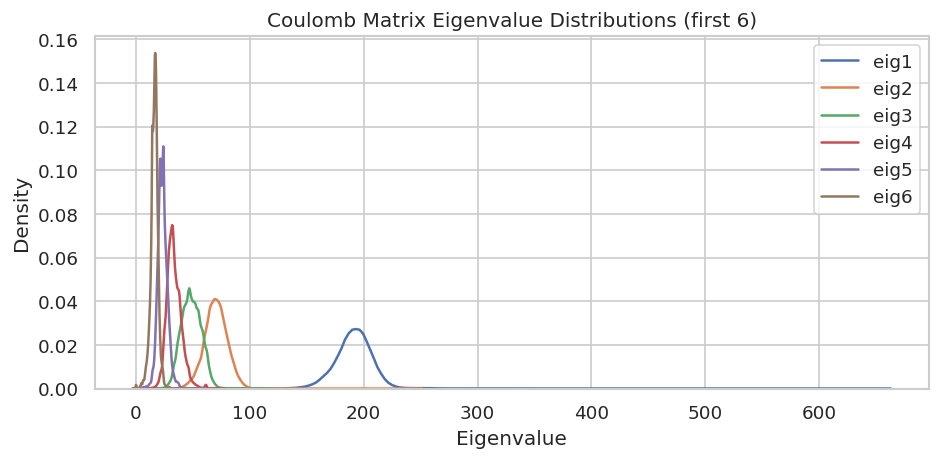

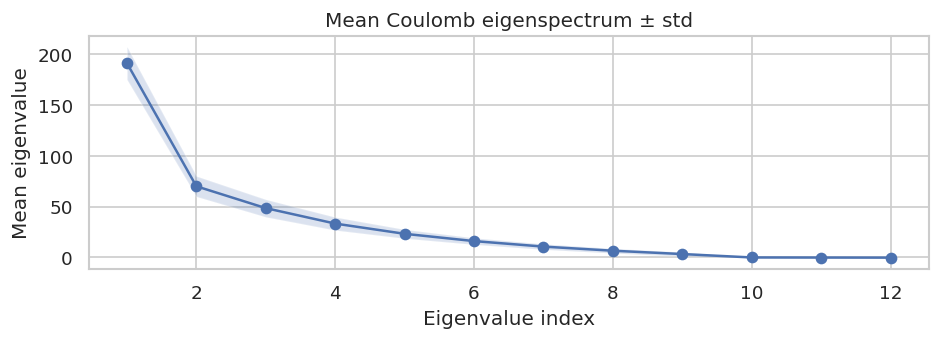

In [21]:
# Stack first 6 eigenvalues across dataset
num_show = min(6, X.shape[1])
plt.figure(figsize=(8,4))
for i in range(num_show):
    sns.kdeplot(X[:, i], label=f'eig{i+1}')
plt.xlabel('Eigenvalue'); plt.title('Coulomb Matrix Eigenvalue Distributions (first {})'.format(num_show))
plt.legend(); plt.tight_layout(); plt.show()

# Alternatively plot mean spectrum with std
mean_spec = X.mean(axis=0)
std_spec = X.std(axis=0)
plt.figure(figsize=(8,3))
plt.plot(range(1,len(mean_spec)+1), mean_spec, marker='o')
plt.fill_between(range(1,len(mean_spec)+1), mean_spec-std_spec, mean_spec+std_spec, alpha=0.2)
plt.xlabel('Eigenvalue index'); plt.ylabel('Mean eigenvalue'); plt.title('Mean Coulomb eigenspectrum ± std')
plt.tight_layout(); plt.show()


Mol idx 110946 SMILES C[NH2+]CC(C)(C)C(=O)[O-] | Pred 9.427 | True nan


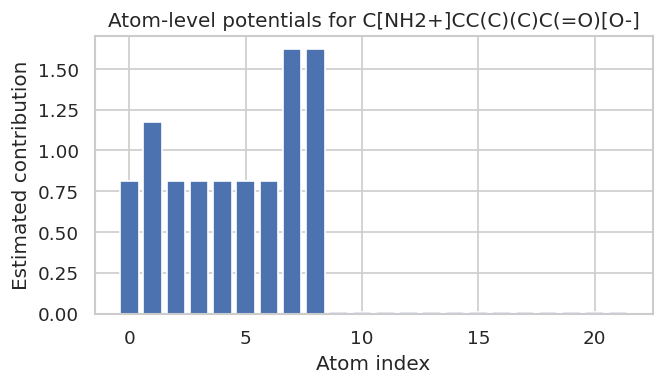

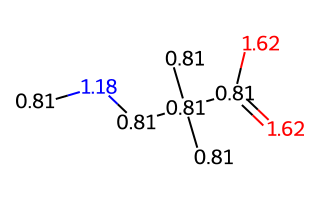

Mol idx 93256 SMILES COC(=O)CC1(O)CC1 | Pred 9.298 | True nan


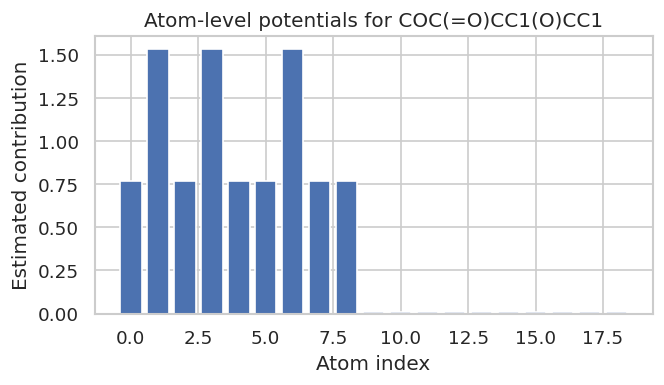

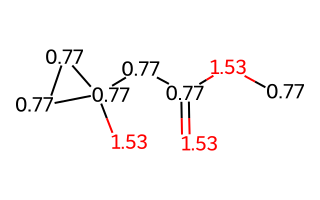

Mol idx 6697 SMILES CC1(C)CCN1C=O | Pred 8.340 | True nan


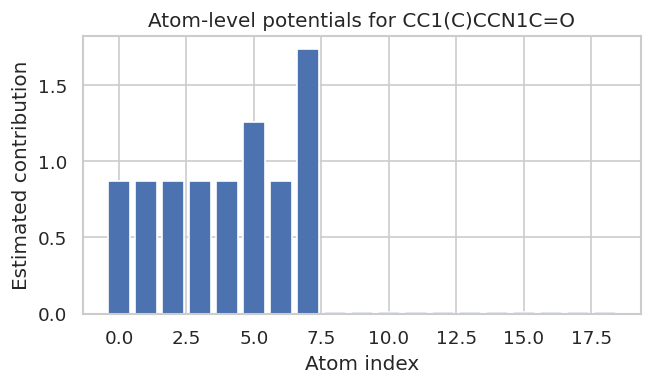

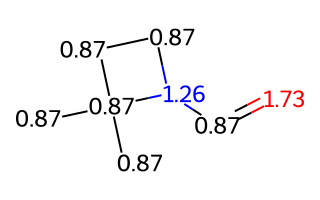

In [25]:
# Function to compute atom-level shares for a molecule
def atom_shares_from_mol(mol):
    N = mol.GetNumAtoms()
    diag_self = np.array([0.5*(atom.GetAtomicNum()**2.4) for atom in mol.GetAtoms()], dtype=float)
    return diag_self / diag_self.sum()

# Compute atom-level potentials for test molecules
atom_pot_list = []
for i in idx_test:
    mol = qm9_df.iloc[i]['mol']
    fm = raw_coulomb_matrix(mol)
    eigs = np.linalg.eigvalsh(fm)
    # Correctly truncate/pad eigenvalues to match the feature dimension X.shape[1]
    padded = np.zeros(X.shape[1])
    num_eigs_to_take = min(len(eigs), X.shape[1])
    padded[:num_eigs_to_take] = np.sort(eigs)[::-1][:num_eigs_to_take]

    z = pca.transform(scaler.transform(padded.reshape(1,-1)))[:, :d]
    pred = lr.predict(z)[0]
    shares = atom_shares_from_mol(mol)
    atom_vals = shares * pred
    atom_pot_list.append((i, qm9_df.iloc[i]['smiles'], atom_vals, pred, float(qm9_df.iloc[i].get('U0', np.nan))))

# Visualize first 3 test molecules
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdDepictor
from IPython.display import SVG, display

def draw_molecule_atom_labels(smiles, atom_vals, width=320, height=200):
    m = Chem.MolFromSmiles(smiles)
    rdDepictor.Compute2DCoords(m)
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    opts = drawer.drawOptions()
    for i in range(m.GetNumAtoms()):
        opts.atomLabels[i] = f"{atom_vals[i]:.2f}"
    drawer.DrawMolecule(m)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    display(SVG(svg))

for j, (idx_m, smi, avals, pred, trueE) in enumerate(atom_pot_list[:3]):
    print(f"Mol idx {idx_m} SMILES {smi} | Pred {pred:.3f} | True {trueE}")
    plt.figure(figsize=(6,3)); plt.bar(range(len(avals)), avals); plt.xlabel('Atom index'); plt.ylabel('Estimated contribution'); plt.title(f'Atom-level potentials for {smi}'); plt.show()
    draw_molecule_atom_labels(smi, avals)

In [26]:
ART_DIR = '/content/artifacts'
os.makedirs(ART_DIR, exist_ok=True)
joblib.dump({'lr': lr, 'pca': pca, 'scaler': scaler}, os.path.join(ART_DIR, 'model_artifacts.pkl'))
np.savez(os.path.join(ART_DIR, 'Xy_smiles.npz'), X=X, y=y, smiles=np.array(smiles_list))
print("Saved artifacts to", ART_DIR)


Saved artifacts to /content/artifacts


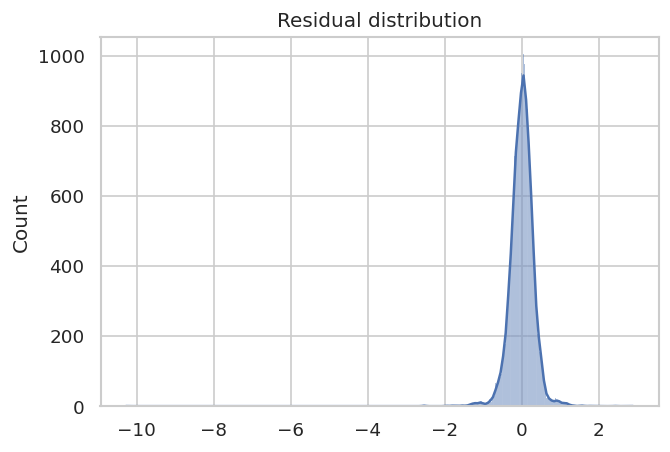

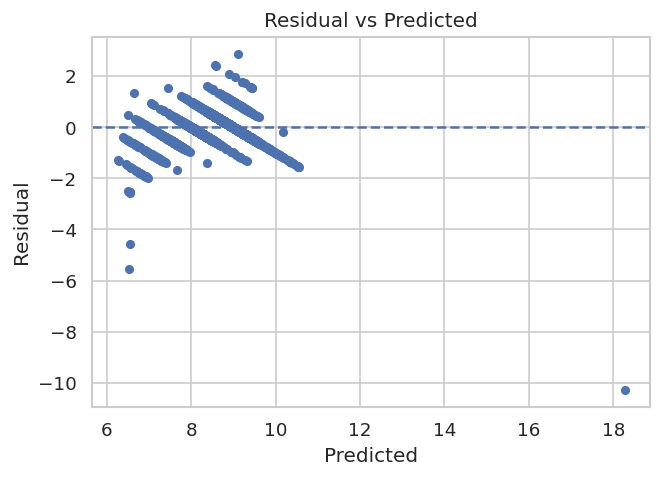

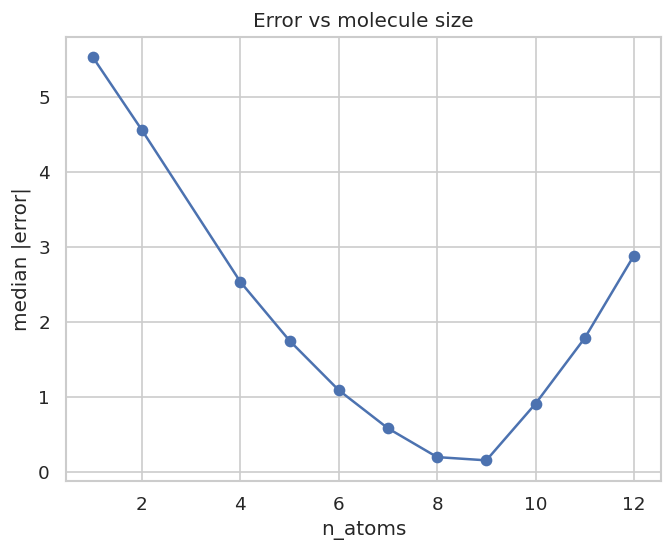

In [27]:
# Residuals distribution, residual vs predicted, residual vs n_atoms
residuals = y_test - y_pred
plt.figure(figsize=(6,4)); sns.histplot(residuals, kde=True); plt.title('Residual distribution'); plt.show()
plt.figure(figsize=(6,4)); plt.scatter(y_pred, residuals, s=20); plt.axhline(0, linestyle='--'); plt.xlabel('Predicted'); plt.ylabel('Residual'); plt.title('Residual vs Predicted'); plt.show()

# MAE by molecule size
test_natoms = qm9_df.iloc[idx_test]['n_atoms'].values
import pandas as pd
df_err = pd.DataFrame({'natoms': test_natoms, 'abs_err': np.abs(residuals)})
df_err.groupby('natoms')['abs_err'].median().plot(marker='o'); plt.xlabel('n_atoms'); plt.ylabel('median |error|'); plt.title('Error vs molecule size'); plt.show()


### Discussion — quick pointers
- Dataset: if QM9 DFT geometries & true U0 are used, performance will be meaningful; with RDKit UFF embed some systematic error expected.
- Descriptor: Coulomb-eigs are a baseline; SOAP/ACSF or raw MO coefficients could improve mapping to Hamiltonian.
- Model: Linear regression on PCA manifold gives interpretability (coefficients) and fast inference; it's a first-order linearization — good for screening/interpretation but limited for strongly non-linear chemistry.
- Atom/Bond attribution is heuristic; treat results as approximate.